# 01 Theorem Data Consistency

Compares the theorem product L_Q L_C with the dataset's DDSR variables. This is a consistency/illustration analysis, not a proof.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
lq=df["qkd_information_leakage"].to_numpy(); lc=df["pqc_adversarial_advantage"].to_numpy()
rh=theorem_product(lq,lc); ok=weak_dominance(lq,lc)
print("Rows satisfying product dominance:",ok.mean())
res=pd.DataFrame({"L_Q":lq,"L_C":lc,"R_H_product":rh,"dominance":ok})
res.describe().to_csv(OUT/"theorem_product_summary.csv"); display(res.describe())

Rows satisfying product dominance: 1.0


,L_Q,L_C,R_H_product
count,520000.000000,520000.000000,520000.000000
mean,0.144462,0.313559,0.048192
std,0.136528,0.091577,0.046917
min,0.002170,0.036840,0.000168
25%,0.027530,0.249860,0.006961
50%,0.096635,0.318820,0.032449
75%,0.232040,0.384700,0.079440
max,0.506880,0.577000,0.234111


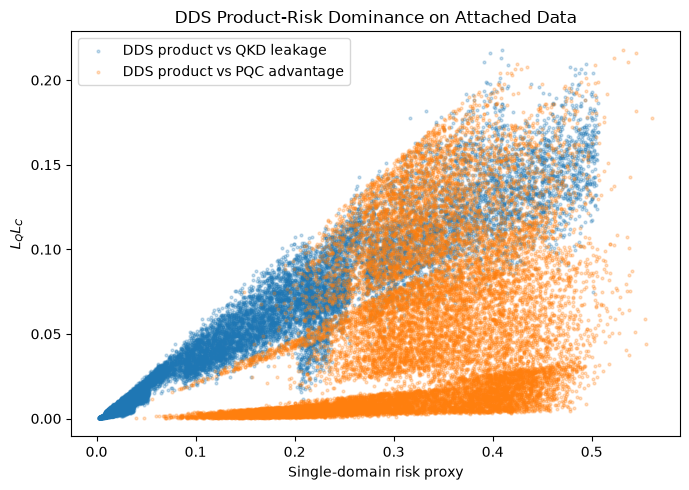

In [3]:
plt.figure(figsize=(7,5)); sample=res.sample(min(20000,len(res)),random_state=42)
plt.scatter(sample["L_Q"],sample["R_H_product"],s=4,alpha=.25,label="DDS product vs QKD leakage")
plt.scatter(sample["L_C"],sample["R_H_product"],s=4,alpha=.25,label="DDS product vs PQC advantage")
plt.xlabel("Single-domain risk proxy"); plt.ylabel(r"$L_Q L_C$"); plt.title("DDS Product-Risk Dominance on Attached Data")
plt.legend(); plt.tight_layout(); plt.savefig(OUT/"fig_product_dominance_data.png",dpi=300); plt.show()